<a href="https://colab.research.google.com/github/jhj5445/portfolio/blob/main/SectorPort.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install hmmlearn
! pip install fredapi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.3 MB/s eta 0:00:00


=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: 4가지 전략 비중 산출 및 국면 확률 추적 중... ===
=== ⚓ 초기 기준점(Initial Anchor) 수립 중 (미래 참조 방지) ===
=== ⚙️ 3-2단계: 실전 매매 백테스트 및 수수료 차감 ===
=== 📊 4단계: 최종 엑스레이(X-ray) 대시보드 출력 ===

Model Name                   | CAGR (%)   | MDD (%)    | Sharpe
--------------------------------------------------------------------------------
1. GMM Pure                  |   10.25 % |  -37.84 % |   0.60
2. HMM Current               |   10.72 % |  -42.08 % |   0.63
3. HMM Hybrid                |   10.74 % |  -42.08 % |   0.63
4. Ensemble (GMM+HMM)        |   10.51 % |  -38.15 % |   0.63
5. Equal Weight (1/N)        |    8.80 % |  -53.57 % |   0.56
--------------------------------------------------------------------------------
SPY (Benchmark)              |    7.77 % |  -55.19 % |   0.48



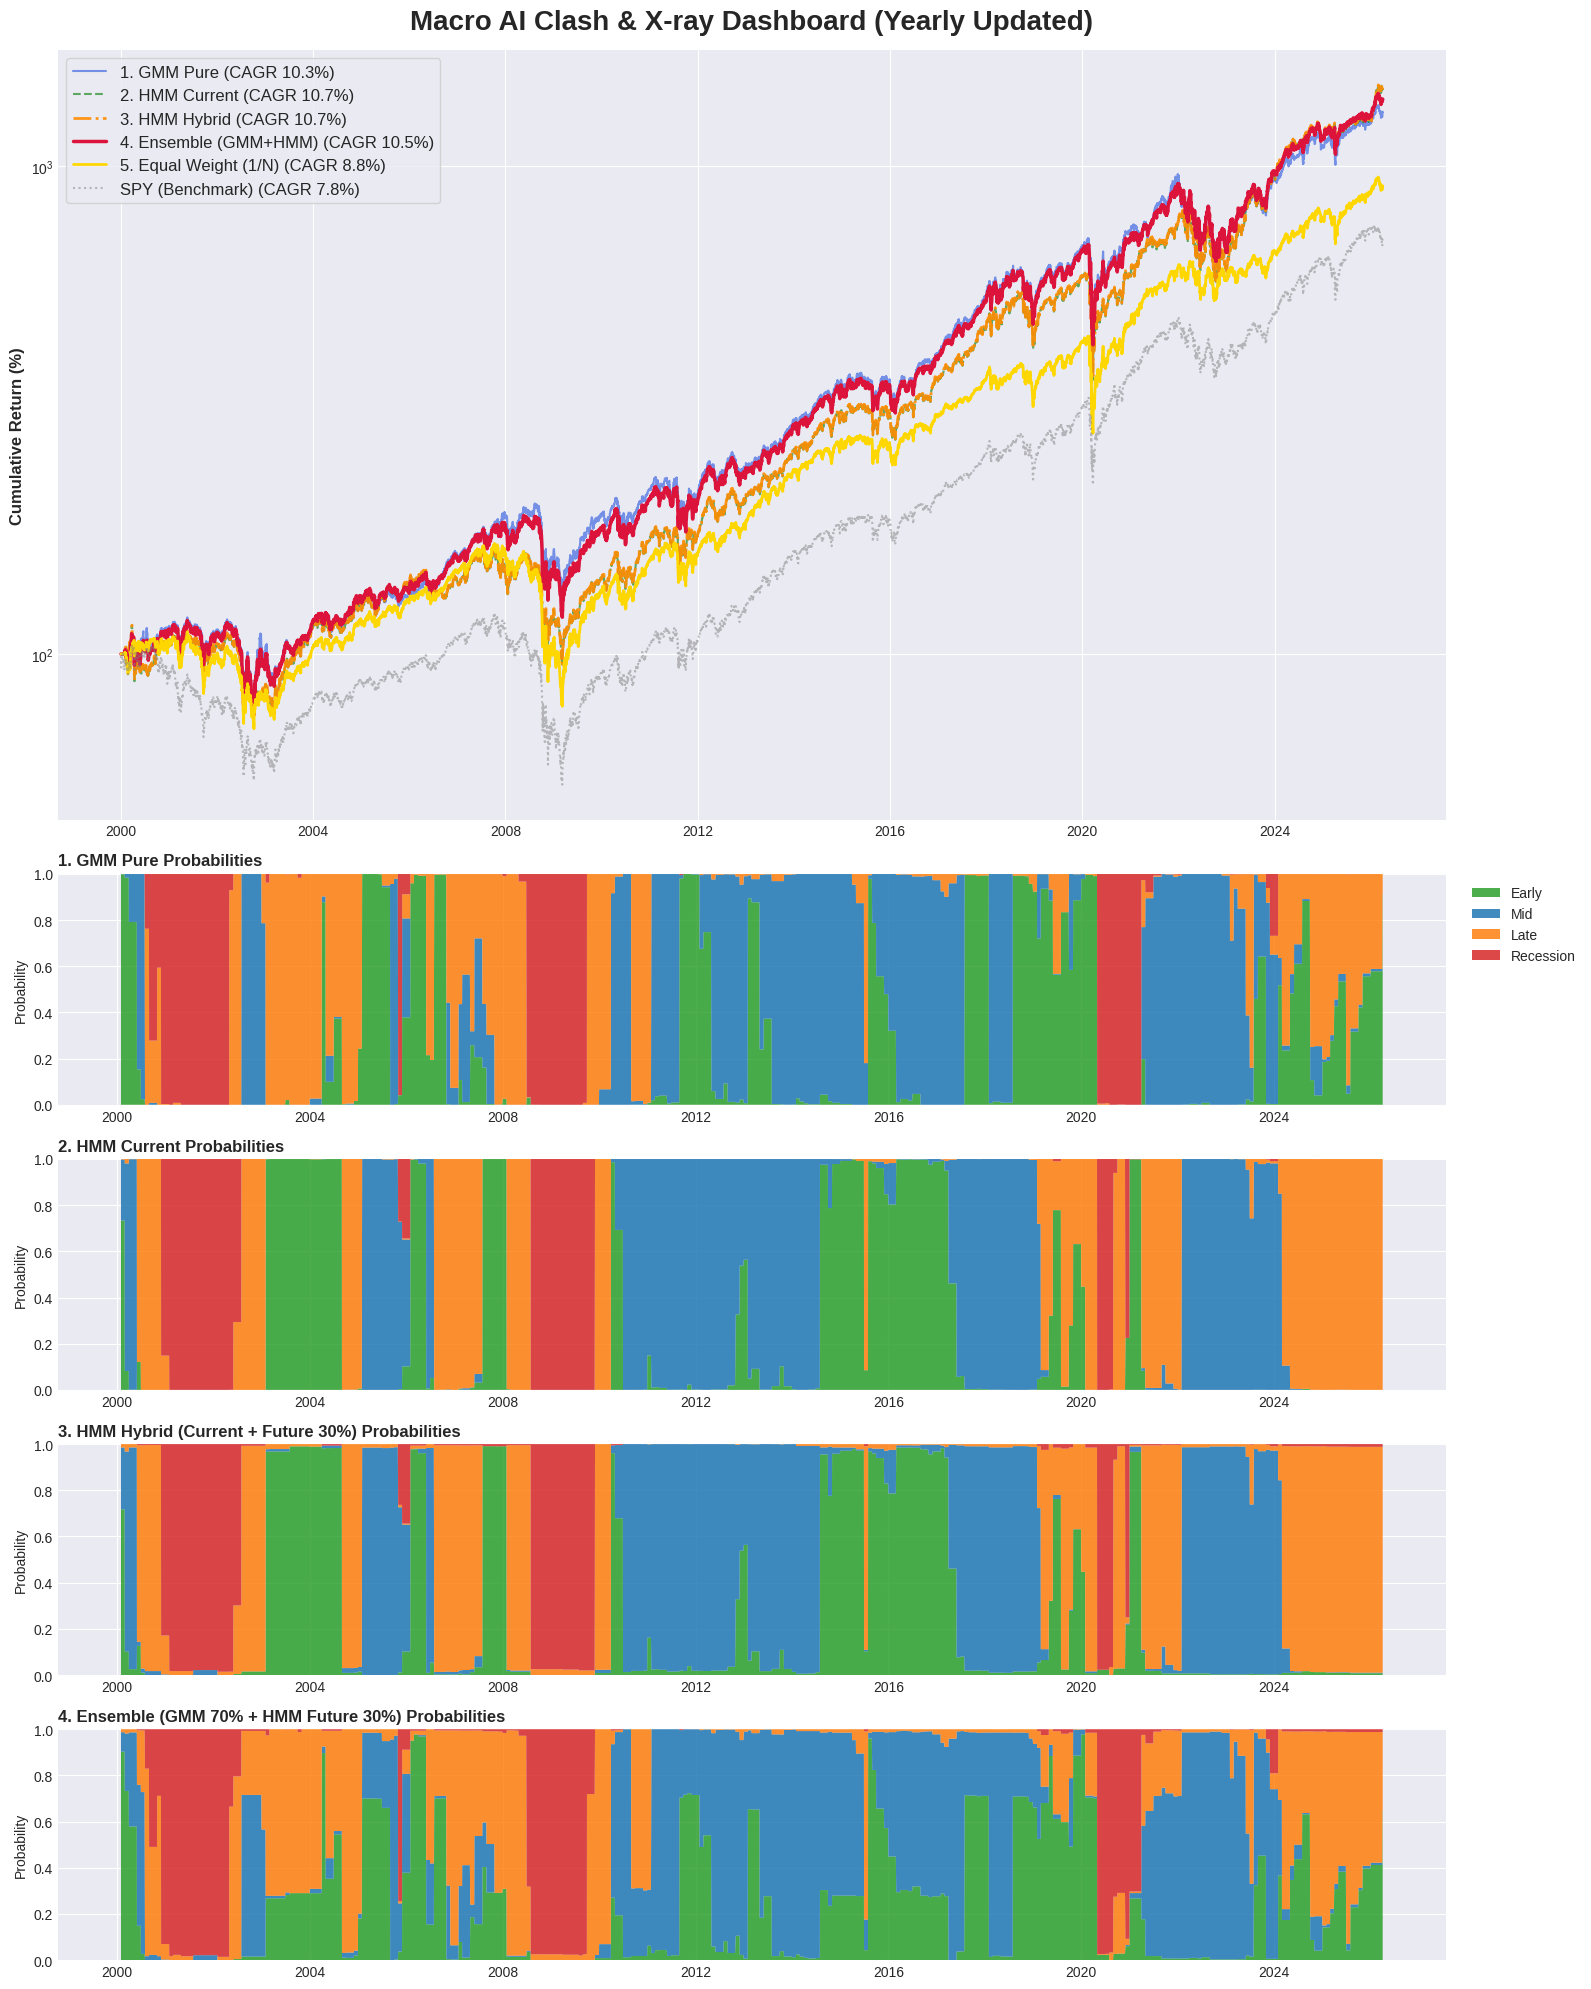

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from hmmlearn.hmm import GaussianHMM
from scipy.spatial.distance import cdist  # 💡 앵커 거리 계산용
from scipy.optimize import linear_sum_assignment
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (120개월 롤링 Z-스코어)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_baa_yield = fred.get_series('BAA')
    s_10y_yield = fred.get_series('GS10')
    s_baa = s_baa_yield - s_10y_yield

    s_indpro = fred.get_series('INDPRO')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')
    s_cpi = fred.get_series('CPIAUCSL')

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_cpi, s_payems, s_t10y2y], axis=1)

    df_macro.columns = ['Growth', 'Credit', 'Capacity','Inflation', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill()

    df_macro['Growth_Mom'] = df_macro['Growth'].pct_change(6)
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(6)
    df_macro['Inf_Mom'] = df_macro['Inflation'].pct_change(12)

    df_macro['Emp_Mom'] = df_macro['Employment'].pct_change(6)
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom','Inf_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(120).mean()) / df_macro[features].rolling(120).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("FRED 서버 접속 불안정.")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (yfinance 에러 방지 적용)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY', 'QQQ', 'VFISX']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

# 💡 yfinance 멀티인덱스 에러를 방지하기 위해 Adj Close를 안전하게 추출
etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
if isinstance(etf_data.columns, pd.MultiIndex):
    etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.levels[0] else etf_data['Close']
else:
    etf_px = etf_data

etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)
test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLU'],
    'Recession': ['XLY','XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 4가지 전략 동시 타겟 비중 산출 및 💡국면 확률 추적!
# ==============================================================================
print("=== ⚙️ 3단계: 4가지 전략 비중 산출 및 국면 확률 추적 중... ===")

eom_dates = etf_px.resample('ME').last().index

tw_m1_gmm = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
tw_m2_hmm_curr = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
tw_m3_hmm_hyb = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
tw_m4_ens = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)

hist_m1, hist_m2, hist_m3, hist_m4 = [], [], [], []

HMM_THRESHOLD = 0.60
FUT_WEIGHT = 0.30
CURR_WEIGHT = 1.0 - FUT_WEIGHT

# --- ⚓ 라벨 고정용 매핑 함수 ---
def get_regime_mapping(centroids):
    growth_sorted_idx = np.argsort(centroids[:, 0])
    idx_recession = growth_sorted_idx[0]
    idx_early = growth_sorted_idx[-1]

    rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
    if centroids[rem_idx[0], 1] > centroids[rem_idx[1], 1]:
        idx_late, idx_mid = rem_idx[0], rem_idx[1]
    else:
        idx_late, idx_mid = rem_idx[1], rem_idx[0]
    return {idx_early: 'Early', idx_mid: 'Mid', idx_late: 'Late', idx_recession: 'Recession'}

def get_stable_regime_mapping(new_means, anchor_centroids):
    labels = ['Early', 'Mid', 'Late', 'Recession']
    anchor_matrix = np.array([anchor_centroids[l] for l in labels])

    # 💡 각 군집 간의 거리(Cost)를 계산
    cost_matrix = cdist(new_means, anchor_matrix, metric='euclidean')

    # 💡 헝가리안 알고리즘을 사용해 중복 없이 '무조건 1:1 매칭' 수행
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    mapping = {}
    for i, j in zip(row_ind, col_ind):
        mapping[i] = labels[j]

    return mapping

def probs_to_weights(probs_dict):
    filtered_probs = {k: v for k, v in probs_dict.items() if v >= 0.10}
    if not filtered_probs:
        dominant = max(probs_dict, key=probs_dict.get)
        filtered_probs = {dominant: 1.0}
    total = sum(filtered_probs.values())
    norm_probs = {k: v / total for k, v in filtered_probs.items()}

    w_series = pd.Series(0.0, index=etf_px.columns)
    for regime, prob in norm_probs.items():
        sectors = cycle_playbook[regime]
        for s in sectors:
            w_series[s] += prob / len(sectors)
    return w_series

# --- ⚓ [수정됨] 1999년 이전 데이터만 이용한 최초 기준점(Initial Anchor) 생성 ---
print("=== ⚓ 초기 기준점(Initial Anchor) 수립 중 (미래 참조 방지) ===")

# 💡 핵심 1: 백테스트 시작 시점('2000-01-01') 이전의 데이터만 잘라내서 최초의 앵커를 만듭니다!
df_train_initial = df_z[df_z.index < '2000-01-01']

base_model = GaussianHMM(n_components=4, covariance_type='diag', random_state=42, n_iter=500)
base_model.fit(df_train_initial)
initial_map = get_regime_mapping(base_model.means_)

anchor_centroids = {name: base_model.means_[idx] for idx, name in initial_map.items()}

# 연간 업데이트된 모델을 담을 변수
current_gmm = None
current_hmm = None
reg_map_gmm = None
reg_map_hmm = None

for date in eom_dates:
    df_train_current = df_z[df_z.index < date]
    if len(df_train_current) > 60:
        current_data = df_train_current.iloc[-1:].values

        # ==========================================
        # 🔄 모델 업데이트 (1년에 한번, 분기별, 반기별, 매달)
        # ==========================================
        #if current_gmm is None or date.month == 1:
        #if current_gmm is None or date.month in [1, 4, 7, 10]:
        if current_gmm is None or date.month in [1, 7]:
        #if  True:
            # 🤖 GMM 학습 및 라벨 고정
            current_gmm = GaussianMixture(n_components=4, covariance_type='diag', random_state=42)
            current_gmm.fit(df_train_current)
            reg_map_gmm = get_stable_regime_mapping(current_gmm.means_, anchor_centroids)

            # 🔮 HMM 학습 및 라벨 고정
            current_hmm = GaussianHMM(n_components=4, covariance_type='diag', random_state=42, n_iter=500, tol=0.01)
            try:
                current_hmm.fit(df_train_current)
                reg_map_hmm = get_stable_regime_mapping(current_hmm.means_, anchor_centroids)
                anchor_centroids = {reg_map_hmm[i]: current_hmm.means_[i] for i in range(4)}
            except:
                pass # 에러 시 기존 모델 유지 (바통도 작년 것을 그대로 유지)

        # ==========================================
        # 📊 매월 평가 (predict는 매달 실행)
        # ==========================================
        try:
            # 🤖 GMM (현재)
            probs_gmm_raw = current_gmm.predict_proba(current_data)[0]
            probs_gmm = {reg_map_gmm[j]: probs_gmm_raw[j] for j in range(4)}
            w_gmm = probs_to_weights(probs_gmm)

            # 🔮 HMM (현재 & 미래)
            curr_proba_hmm_raw = current_hmm.predict_proba(df_train_current)[-1]
            probs_hmm_curr = {reg_map_hmm[j]: curr_proba_hmm_raw[j] for j in range(4)}
            w_hmm_curr = probs_to_weights(probs_hmm_curr)

            next_proba_hmm_raw = np.dot(curr_proba_hmm_raw, current_hmm.transmat_)
            probs_hmm_fut = {reg_map_hmm[j]: next_proba_hmm_raw[j] for j in range(4)}
            w_hmm_fut = probs_to_weights(probs_hmm_fut)

            max_fut_prob = max(probs_hmm_fut.values())
            is_confident = max_fut_prob >= HMM_THRESHOLD
            curr_dominant = max(probs_hmm_curr, key=probs_hmm_curr.get)

            # 💡 [추격자 포착 로직]
            if is_confident:
                challenger_state = None
                challenger_prob = 0.0
                for state, prob in probs_hmm_fut.items():
                    if state != curr_dominant and prob > challenger_prob:
                        challenger_state = state
                        challenger_prob = prob

                if challenger_prob >= 0.20:
                    pass # 필요 시 출력: print(f"👀 [변화 조짐] {date.strftime('%Y-%m-%d')} ...")

        except Exception as e:
            w_hmm_curr, w_hmm_fut = w_gmm.copy(), w_gmm.copy()
            probs_hmm_curr, probs_hmm_fut = probs_gmm.copy(), probs_gmm.copy()
            is_confident = False

        # --- 🏆 비중 할당 및 확률 기록 ---
        tw_m1_gmm.loc[date] = w_gmm
        hist_m1.append({'Date': date, **probs_gmm})

        tw_m2_hmm_curr.loc[date] = w_hmm_curr
        hist_m2.append({'Date': date, **probs_hmm_curr})

        if is_confident:
            tw_m3_hmm_hyb.loc[date] = (w_hmm_curr * CURR_WEIGHT) + (w_hmm_fut * FUT_WEIGHT)
            hyb_probs = {k: (probs_hmm_curr[k] * CURR_WEIGHT) + (probs_hmm_fut[k] * FUT_WEIGHT) for k in cycle_playbook.keys()}
        else:
            tw_m3_hmm_hyb.loc[date] = w_hmm_curr
            hyb_probs = probs_hmm_curr.copy()
        hist_m3.append({'Date': date, **hyb_probs})

        if is_confident:
            tw_m4_ens.loc[date] = (w_gmm * CURR_WEIGHT) + (w_hmm_fut * FUT_WEIGHT)
            ens_probs = {k: (probs_gmm[k] * CURR_WEIGHT) + (probs_hmm_fut[k] * FUT_WEIGHT) for k in cycle_playbook.keys()}
        else:
            tw_m4_ens.loc[date] = w_gmm
            ens_probs = probs_gmm.copy()
        hist_m4.append({'Date': date, **ens_probs})

    else:
        for tw in [tw_m1_gmm, tw_m2_hmm_curr, tw_m3_hmm_hyb, tw_m4_ens]:
            tw.loc[date, 'SPY'] = 1.0
sector_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB']
tw_ew = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
tw_ew[sector_tickers] = 1.0 / len(sector_tickers)# DataFrame으로 변환
df_prob_m1 = pd.DataFrame(hist_m1).set_index('Date')
df_prob_m2 = pd.DataFrame(hist_m2).set_index('Date')
df_prob_m3 = pd.DataFrame(hist_m3).set_index('Date')
df_prob_m4 = pd.DataFrame(hist_m4).set_index('Date')

# ==============================================================================
# 3-2. ⚙️ 시뮬레이터 (수수료 적용)
# ==============================================================================
print("=== ⚙️ 3-2단계: 실전 매매 백테스트 및 수수료 차감 ===")
target_months = eom_dates.to_period('M')
last_trading_days = daily_returns.groupby(daily_returns.index.to_period('M')).apply(lambda x: x.index[-1])
aligned_index = target_months.map(last_trading_days)

def run_simulation(tw_df):
    tw = tw_df.copy()
    tw.index = aligned_index
    tw = tw[tw.index.notna()]

    tw_aligned = tw.reindex(daily_returns.index)
    reb_signals = tw_aligned.shift(1)
    is_reb_day = ~reb_signals.isna().all(axis=1)

    zero_mask = is_reb_day & (reb_signals.sum(axis=1) == 0)
    reb_signals.loc[zero_mask, 'SPY'] = 1.0

    r_vals = daily_returns.values
    t_vals = reb_signals.fillna(0.0).values
    reb_day_arr = is_reb_day.values

    n_d = len(daily_returns)
    n_a = len(daily_returns.columns)

    port_ret = np.zeros(n_d)
    c_weights = np.zeros(n_a)
    fee_rate = 0.002

    for i in range(n_d):
        if reb_day_arr[i]:
            target_w = t_vals[i]
            cost = np.sum(np.abs(target_w - c_weights)) * fee_rate
            c_weights = target_w.copy()
        else:
            cost = 0.0

        day_r = np.sum(c_weights * r_vals[i])
        port_ret[i] = day_r - cost

        if (1 + day_r) > 0: c_weights = c_weights * (1 + r_vals[i]) / (1 + day_r)
        else: c_weights = np.zeros(n_a)

    return pd.Series(port_ret, index=daily_returns.index)

ret_m1 = run_simulation(tw_m1_gmm)
ret_m2 = run_simulation(tw_m2_hmm_curr)
ret_m3 = run_simulation(tw_m3_hmm_hyb)
ret_m4 = run_simulation(tw_m4_ens)
ret_ew = run_simulation(tw_ew)
# ==============================================================================
# 4. 🚀 성과 비교 및 📊 뇌구조(Regime) 대시보드 시각화
# ==============================================================================
print("=== 📊 4단계: 최종 엑스레이(X-ray) 대시보드 출력 ===")

valid_start = '2000-01-01'
rets = {
    '1. GMM Pure': ret_m1.loc[valid_start:],
    '2. HMM Current': ret_m2.loc[valid_start:],
    '3. HMM Hybrid': ret_m3.loc[valid_start:],
    '4. Ensemble (GMM+HMM)': ret_m4.loc[valid_start:],
    '5. Equal Weight (1/N)': ret_ew.loc[valid_start:],
    'SPY (Benchmark)': daily_returns.loc[valid_start:, 'SPY']
}
cums = {name: (1 + ret).cumprod() for name, ret in rets.items()}

# --- 성과 텍스트 출력 ---
def get_metrics(ret, cum):
    years = len(cum) / 252
    cagr = (cum.iloc[-1] ** (1 / years)) - 1
    mdd = (cum / cum.cummax() - 1).min()
    sharpe = (ret.mean() / ret.std()) * np.sqrt(252)
    return cagr, mdd, sharpe

print("\n" + "="*80)
print(f"{'Model Name':<28} | {'CAGR (%)':<10} | {'MDD (%)':<10} | {'Sharpe'}")
print("-" * 80)
for name in rets.keys():
    c, m, s = get_metrics(rets[name], cums[name])
    if 'SPY' in name: print("-" * 80)
    print(f"{name:<28} | {c*100:>7.2f} % | {m*100:>7.2f} % | {s:>6.2f}")
print("="*80 + "\n")

# --- 📊 5단 대시보드 그리기 ---
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(5, 1, figsize=(16, 20), gridspec_kw={'height_ratios': [4, 1.2, 1.2, 1.2, 1.2]})

# [1] 최상단: 누적 수익률 배틀
colors = ['royalblue', 'forestgreen', 'darkorange', 'crimson', 'gold', 'gray']

styles = ['-', '--', '-.', '-', '-', ':']

linewidths = [1.5, 1.5, 2, 2.5, 2.0, 1.5]
alphas = [0.7, 0.7, 0.9, 1.0, 1.0, 0.5]

for i, name in enumerate(cums.keys()):
    label_name = f"{name} (CAGR {get_metrics(rets[name], cums[name])[0]*100:.1f}%)"
    axes[0].plot(cums[name].index, cums[name] * 100, label=label_name,
                 color=colors[i], linestyle=styles[i], linewidth=linewidths[i], alpha=alphas[i])

axes[0].set_title('Macro AI Clash & X-ray Dashboard (Yearly Updated)', fontsize=20, fontweight='bold', pad=15)
axes[0].set_ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
axes[0].set_yscale('log')
axes[0].legend(loc='upper left', fontsize=12, frameon=True)

# [2~5] 하단: 각 모델의 뇌구조 (국면 확률)
regime_dfs = [
    (df_prob_m1, '1. GMM Pure Probabilities'),
    (df_prob_m2, '2. HMM Current Probabilities'),
    (df_prob_m3, '3. HMM Hybrid (Current + Future 30%) Probabilities'),
    (df_prob_m4, '4. Ensemble (GMM 70% + HMM Future 30%) Probabilities')
]

regime_colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'] # Green(Early), Blue(Mid), Orange(Late), Red(Recession)
labels = ['Early', 'Mid', 'Late', 'Recession']

for i, (df_prob, title) in enumerate(regime_dfs):
    ax = axes[i+1]
    probs_aligned = df_prob.reindex(cums['1. GMM Pure'].index).ffill().dropna()
    probs_aligned = probs_aligned[labels].div(probs_aligned[labels].sum(axis=1), axis=0)

    ax.stackplot(probs_aligned.index,
                 probs_aligned['Early'], probs_aligned['Mid'],
                 probs_aligned['Late'], probs_aligned['Recession'],
                 labels=labels, colors=regime_colors, alpha=0.85)

    ax.set_title(title, fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1)
    if i == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=10)

plt.tight_layout()
plt.show()

=== 🔍 5단계: CFNAI 지수와의 교차 검증 ===


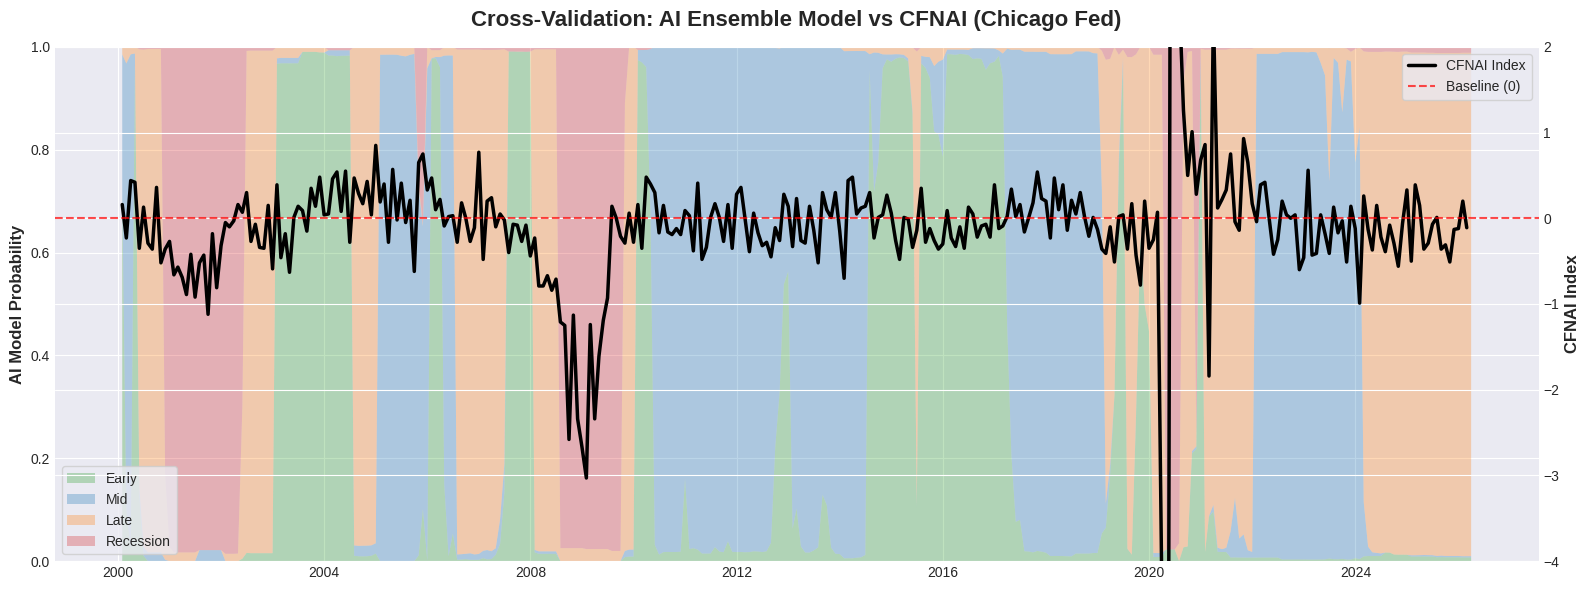

In [6]:
# ==============================================================================
# 5. 🔍 모델 검증: 시카고 연은 국가활동지수(CFNAI) vs AI 앙상블 모델 비교
# ==============================================================================
print("=== 🔍 5단계: CFNAI 지수와의 교차 검증 ===")

try:
    # 💡 FRED에서 미국 CFNAI 데이터 호출 (티커: CFNAI 변경 완료!)
    s_cfnai = fred.get_series('CFNAI')
    df_cfnai = pd.DataFrame(s_cfnai, columns=['CFNAI']).resample('ME').last().ffill()

    # 시각화할 날짜 구간 설정 (2000년 이후)
    val_start = '2000-01-01'
    df_cfnai_val = df_cfnai.loc[val_start:end_date]

    probs_val = df_prob_m3.loc[val_start:end_date].ffill().dropna()
    probs_val = probs_val[['Early', 'Mid', 'Late', 'Recession']].div(probs_val[['Early', 'Mid', 'Late', 'Recession']].sum(axis=1), axis=0)

    # --- 📊 교차 검증 시각화 ---
    fig2, ax1 = plt.subplots(figsize=(16, 6))

    # 1) 하단 배경: AI 모델의 국면 확률 (Stackplot)
    regime_colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'] # Green, Blue, Orange, Red
    ax1.stackplot(probs_val.index,
                  probs_val['Early'], probs_val['Mid'],
                  probs_val['Late'], probs_val['Recession'],
                  labels=['Early', 'Mid', 'Late', 'Recession'],
                  colors=regime_colors, alpha=0.3)

    ax1.set_ylabel('AI Model Probability', fontsize=12, fontweight='bold')
    ax1.set_ylim(0, 1)
    ax1.legend(loc='lower left', fontsize=10, frameon=True)

    # 2) 상단 라인: CFNAI 지수 (Twin Y-axis)
    ax2 = ax1.twinx()
    # 💡 선 데이터와 라벨 이름도 CFNAI로 맞춤!
    ax2.plot(df_cfnai_val.index, df_cfnai_val['CFNAI'], color='black', linewidth=2.5, label='CFNAI Index')
    # 💡 기준선 0으로 설정 완료!
    ax2.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Baseline (0)')

    ax2.set_ylabel('CFNAI Index', fontsize=12, fontweight='bold')

    # 축 여유 공간 설정
    cfnai_min, cfnai_max = df_cfnai_val['CFNAI'].min(), df_cfnai_val['CFNAI'].max()
    # 💡 코로나 아웃라이어를 무시하고 정상 범위(-4 ~ +2)로 강제 줌인!
    ax2.set_ylim(-4, 2)
    ax2.legend(loc='upper right', fontsize=10, frameon=True)

    plt.title('Cross-Validation: AI Ensemble Model vs CFNAI (Chicago Fed)', fontsize=16, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

# 💡 except 문 아래의 불필요한 중복 코드 제거 완료!
except Exception as e:
    print(f"🚨 CFNAI 데이터 로드 또는 시각화 오류: {e}")

=== 📊 5단계: 연도별 수익률 차트 생성 ===


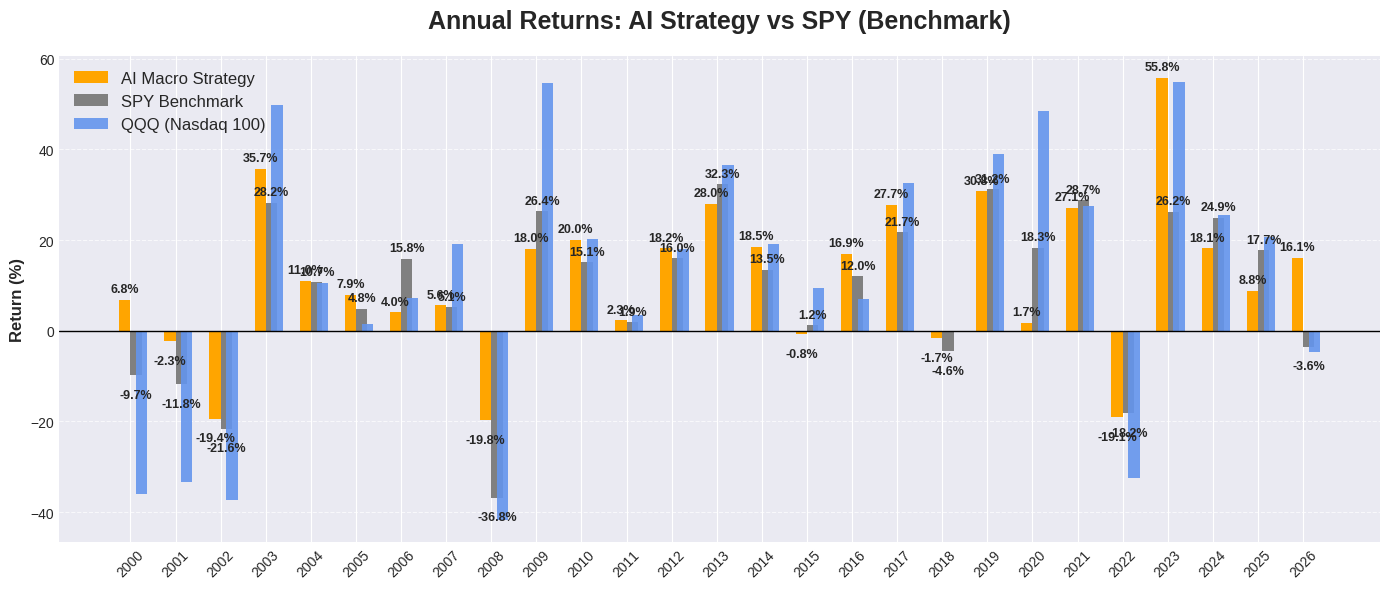

In [10]:
# ==============================================================================
# 5. 📊 연도별 수익률 (Annual Return) 바 차트 시각화
# ==============================================================================
print("=== 📊 5단계: 연도별 수익률 차트 생성 ===")
qqq_ret_valid = daily_returns.loc[valid_start:, 'QQQ']
spy_ret_valid = daily_returns.loc[valid_start:, 'SPY']
annual_ai = (1 + ret_m3).resample('YE').prod() - 1
annual_spy = (1 + spy_ret_valid).resample('YE').prod() - 1
annual_qqq = (1 + qqq_ret_valid).resample('YE').prod() - 1
years = annual_ai.index.year
width = 0.25

fig_annual, ax_annual = plt.subplots(figsize=(14, 6))

bars_ai = ax_annual.bar(years - width/2, annual_ai * 100, width, label='AI Macro Strategy', color='orange')
bars_spy = ax_annual.bar(years + width/2, annual_spy * 100, width, label='SPY Benchmark', color='gray')
bars_qqq = ax_annual.bar(years + width, annual_qqq * 100, width, label='QQQ (Nasdaq 100)', color='cornflowerblue', alpha=0.9)
ax_annual.set_title('Annual Returns: AI Strategy vs SPY (Benchmark)', fontsize=18, fontweight='bold', pad=20)
ax_annual.set_ylabel('Return (%)', fontsize=12, fontweight='bold')
ax_annual.set_xticks(years)
ax_annual.set_xticklabels(years, rotation=45)
ax_annual.axhline(0, color='black', linewidth=1) # 0% 기준선
ax_annual.legend(fontsize=12, loc='upper left')
ax_annual.grid(axis='y', linestyle='--', alpha=0.7)

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ypos = height + 1 if height > 0 else height - 3
        ax_annual.text(bar.get_x() + bar.get_width()/2., ypos,
                       f'{height:.1f}%',
                       ha='center', va='bottom' if height > 0 else 'top',
                       fontsize=9, fontweight='bold')

add_labels(bars_ai)
add_labels(bars_spy)

plt.tight_layout()
plt.show()